In [2]:
from helpers import AllExperiments
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
import re
from collections import Counter
from scipy.optimize import curve_fit
from helpers.data_extractors.labbook_reader import LabBookHelper


lb: pd.DataFrame = AllExperiments().read_labbook()
all_data = AllExperiments(confidence=69.95, cache=True, labbook=lb)
exps: list[str] = ["MYW_34_L", "ARM_07"]
all_data.smart_read(exps)
df = all_data.return_full_analysis()
pth = Path(all_data.folder_path_for_assembly)


Reading data from folder Orbitrap Lumos>Mary>20240705: 100%|██████████| 27/27 [00:06<00:00,  4.39it/s]
Reading data from folder Alasdair Macleod>28-08-23>ARM_07_mzml: 100%|██████████| 60/60 [00:00<00:00, 157.18it/s]
Calculating metrics: 100%|██████████| 87/87 [00:00<00:00, 193.11it/s]


In [3]:
def extract_assembly_index(sequence: str) -> int:
    with open(pth / f"{sequence}.txt", "r") as file:
        content = file.read()
    match = re.search(r"Assembly Index:\s*(\d+)", content)
    if match:
        return int(match.group(1))
    else:
        raise ValueError("No assembly index found in the file")


def ma_distributions(name: str) -> dict[str, list[int]]:
    return {
        key: [extract_assembly_index(i) for i in value[0]]
        for key, value in LabBookHelper(lb)
        .get_experiment_data_dict(df, name)
        .items()
    }


plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = ["Arial"]
arial_font = {"family": "Arial", "size": 10}


def gaussian(x, amp, mean, std):
    return amp * np.exp(-((x - mean) ** 2) / (2 * std**2))


def simple_histogram(
    data, figsize=(7, 5), xlim=(0, 6), save_figure: str | None = None
) -> None:
    """Simple black and white histogram with points and Gaussian fit for single dataset"""
    fig, ax = plt.subplots(figsize=figsize)

    # Handle both dictionary and list inputs
    if isinstance(data, dict):
        # If dictionary, take the first dataset
        key, values = next(iter(data.items()))
    else:
        # If list, use directly
        values = data

    counter = Counter(values)
    unique_values = sorted(counter.keys())
    counts = [counter[val] for val in unique_values]

    # Fit Gaussian first if enough data points
    if len(unique_values) > 3:
        try:
            amp_guess = max(counts)
            mean_guess = unique_values[np.argmax(counts)]
            std_guess = np.std(unique_values)

            popt, _ = curve_fit(
                gaussian,
                unique_values,
                counts,
                p0=[amp_guess, mean_guess, std_guess],
            )

            # Plot Gaussian fit (extended range)
            x_range = max(unique_values) - min(unique_values)
            x_start = min(unique_values) - 0.5 * x_range
            x_end = max(unique_values) + 0.5 * x_range
            x_fit = np.linspace(x_start, x_end, 200)
            y_fit = gaussian(x_fit, *popt)
            ax.plot(x_fit, y_fit, "--", alpha=0.6, color="black", linewidth=1.5)

            # Add short vertical bar at Gaussian peak and label
            peak_x = popt[1]  # mean of Gaussian
            peak_y = popt[0]  # amplitude of Gaussian
            # Draw a short vertical line from 95% of peak down to 70% of peak height
            bar_top = peak_y * 0.95
            bar_bottom = peak_y * 0.7
            ax.plot(
                [peak_x, peak_x],
                [bar_top, bar_bottom],
                color="black",
                linestyle="-",
                linewidth=2,
                alpha=0.8,
            )
            # Put text below the bar
            ax.text(
                peak_x,
                bar_bottom - peak_y * 0.05,
                f"{peak_x:.1f}",
                fontdict=arial_font,
                ha="center",
                va="top",
            )

        except Exception as e:
            print(f"Could not fit Gaussian: {e}")

    # Plot scatter points on top (after Gaussian)
    ax.scatter(
        unique_values,
        counts,
        facecolors="lightgray",
        edgecolors="black",
        s=50,
        alpha=0.8,
        linewidths=1,
    )

    ax.set_xlabel("Polymer Assembly", fontdict=arial_font)
    ax.set_ylabel("Frequency", fontdict=arial_font)
    ax.set_title("Polymer Assembly Distribution", fontdict=arial_font)
    ax.tick_params(axis="both", which="major", labelsize=arial_font["size"])

    # Set font for tick labels
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname("Arial")

    # Remove grid
    ax.grid(False)

    # Set limits and integer ticks on x-axis
    ax.set_xlim(xlim)
    ax.set_xticks(range(int(xlim[0]), int(xlim[1]) + 1))

    # Make background white
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")

    plt.tight_layout()
    if save_figure:
        plt.savefig(save_figure, dpi=300)
    plt.show()

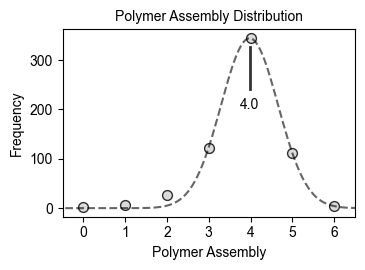

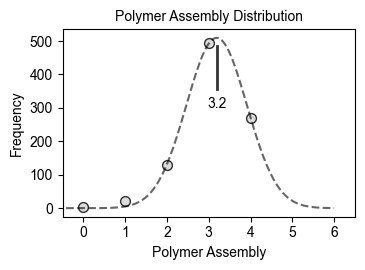

In [4]:
simple_histogram(
    ma_distributions("MYW_34_L")["ripper_20240704_MYW_34_L_6"],
    figsize=(3.75, 2.8),
    xlim=(-0.5, 6.5),
    save_figure="Figures_manuscript/MA_distribution_Figure_6_MA_distribution_selection.png",
)
simple_histogram(
    ma_distributions("ARM_07_1")["ripper_ARM_07_07"],
    figsize=(3.75, 2.8),
    xlim=(-0.5, 6.5),
    save_figure="Figures_manuscript/MA_distribution_Figure_6_MA_distribution_no_selection.png",
)